# Question 4: Clustering - Unsupervised Learning

## Objective
The goal of this task is to compare clustering algorithms and evaluate cluster quality using internal clustering metrics.

## Dataset
The Wholesale Customers Dataset is originally obtained from the UCI Machine Learning Repository.
https://archive.ics.uci.edu/dataset/292/wholesale+customers

In [ ]:
pip install ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
wholesale_customers = fetch_ucirepo(id=292)

# data (as pandas dataframes)
X = wholesale_customers.data.features
y = wholesale_customers.data.targets

# metadata
print(wholesale_customers.metadata)

# variable information
print(wholesale_customers.variables)


{'uci_id': 292, 'name': 'Wholesale customers', 'repository_url': 'https://archive.ics.uci.edu/dataset/292/wholesale+customers', 'data_url': 'https://archive.ics.uci.edu/static/public/292/data.csv', 'abstract': 'The data set refers to clients of a wholesale distributor. It includes the annual spending in monetary units (m.u.) on diverse product categories', 'area': 'Business', 'tasks': ['Classification', 'Clustering'], 'characteristics': ['Multivariate'], 'num_instances': 440, 'num_features': 7, 'feature_types': ['Integer'], 'demographics': [], 'target_col': ['Region'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2013, 'last_updated': 'Mon Feb 05 2024', 'dataset_doi': '10.24432/C5030X', 'creators': ['Margarida Cardoso'], 'intro_paper': None, 'additional_info': {'summary': None, 'purpose': None, 'funded_by': None, 'instances_represent': None, 'recommended_data_splits': None, 'sensitive_data': None, 'preprocessing_description':

In [ ]:
df = wholesale_customers.data.features.copy()
df.head()

,Channel,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,12669,9656,7561,214,2674,1338
1,2,7057,9810,9568,1762,3293,1776
2,2,6353,8808,7684,2405,3516,7844
3,1,13265,1196,4221,6404,507,1788
4,2,22615,5410,7198,3915,1777,5185


## Exploratory Data Analysis

The dataset contains 440 observations and 7 features. All features are numerical and no missing values are present. The variables represent annual spending in different product categories, with noticeable differences in scale across features.

In [ ]:
df.shape

(440, 7)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Fresh             440 non-null    int64
 2   Milk              440 non-null    int64
 3   Grocery           440 non-null    int64
 4   Frozen            440 non-null    int64
 5   Detergents_Paper  440 non-null    int64
 6   Delicassen        440 non-null    int64
dtypes: int64(7)
memory usage: 24.2 KB


In [ ]:
df.describe()

,Channel,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,1.322727,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,0.468052,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,1.000000,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,1.000000,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,1.000000,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,2.000000,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,2.000000,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000


## Feature Scaling

The dataset is standardized using StandardScaler to ensure all features contribute equally to the clustering process. The 'Channel' variable is excluded as it represents categorical information.

In [ ]:
X = df.drop("Channel", axis=1)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
X_scaled[:5]

array([[ 0.05293319,  0.52356777, -0.04111489, -0.58936716, -0.04356873,
        -0.06633906],
       [-0.39130197,  0.54445767,  0.17031835, -0.27013618,  0.08640684,
         0.08915105],
       [-0.44702926,  0.40853771, -0.0281571 , -0.13753572,  0.13323164,
         2.24329255],
       [ 0.10011141, -0.62401993, -0.3929769 ,  0.6871443 , -0.49858822,
         0.09341105],
       [ 0.84023948, -0.05239645, -0.07935618,  0.17385884, -0.23191782,
         1.29934689]])

##K-Means

In [ ]:
from sklearn.cluster import KMeans

inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=123, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

## Elbow Method

The elbow plot shows a sharp decrease in inertia up to k=5, after which the rate of decrease slows down. This suggests that the optimal number of clusters is around 5.

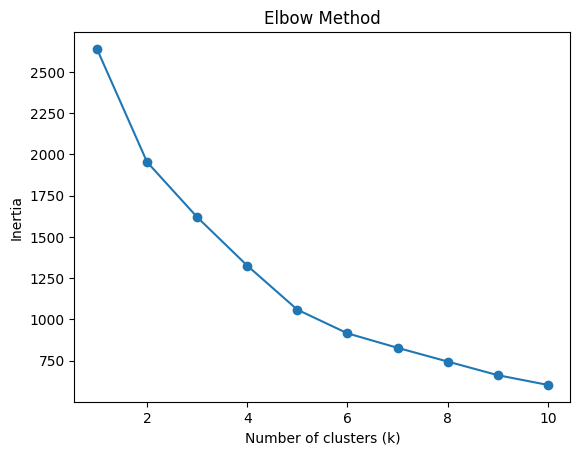

In [ ]:
import matplotlib.pyplot as plt

plt.plot(K_range, inertia, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

##Silhouette Score

In [ ]:
from sklearn.metrics import silhouette_score

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=123, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"k={k}, silhouette={score:.3f}")

k=2, silhouette=0.591
k=3, silhouette=0.334
k=4, silhouette=0.404
k=5, silhouette=0.368
k=6, silhouette=0.374
k=7, silhouette=0.286
k=8, silhouette=0.290
k=9, silhouette=0.312
k=10, silhouette=0.318


## Optimal Number of Clusters

While the elbow method suggested k ≈ 5, the silhouette score clearly indicates that k = 2 provides the best cluster separation, with the highest score of 0.591.

Therefore, k = 2 is selected as the optimal number of clusters.

##K-Means Clustering (k=2)

In [ ]:
kmeans_final = KMeans(n_clusters=2, random_state=123, n_init=10)
labels_kmeans = kmeans_final.fit_predict(X_scaled)

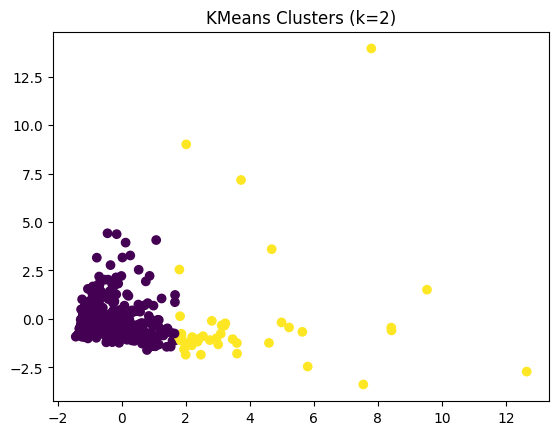

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

import matplotlib.pyplot as plt

plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_kmeans, cmap='viridis')
plt.title("KMeans Clusters (k=2)")
plt.show()

The clustering result shows two distinct groups. One cluster is compact and dense, while the other is more spread out.

This suggests that customers can be broadly divided into low-spending and high-spending groups based on their purchasing behavior.

In [ ]:
df["Cluster"] = labels_kmeans

df.groupby("Cluster").mean()

,Channel,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Cluster,,,,,,,
0,1.261307,11915.653266,4236.944724,5724.791457,2905.017588,1768.944724,1258.778894
1,1.904762,12802.404762,20572.690476,29049.880952,4653.642857,13424.214286,4046.404762


In [ ]:
df.groupby("Cluster")["Channel"].value_counts()

Cluster  Channel
0        1          294
         2          104
1        2           38
         1            4
Name: count, dtype: int64

##Agglomerative Clustering (Ward)

In [ ]:
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(n_clusters=2, linkage='ward')
labels_agg = agg.fit_predict(X_scaled)

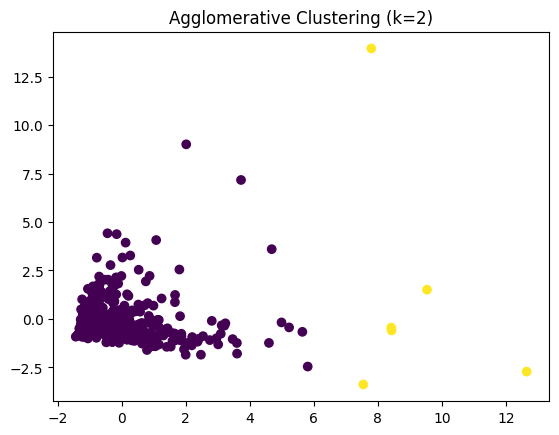

In [ ]:
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_agg, cmap='viridis')
plt.title("Agglomerative Clustering (k=2)")
plt.show()

Agglomerative clustering with Ward linkage produces a clustering structure very similar to K-Means. Both methods identify two main groups, indicating consistent clustering patterns in the dataset.

This suggests that the data naturally forms two main clusters.

##DBSCAN
DBSCAN identifies one main cluster and several outliers. The algorithm groups dense regions together and labels isolated points as noise.

This shows that the dataset has a dominant cluster with a few atypical observations.

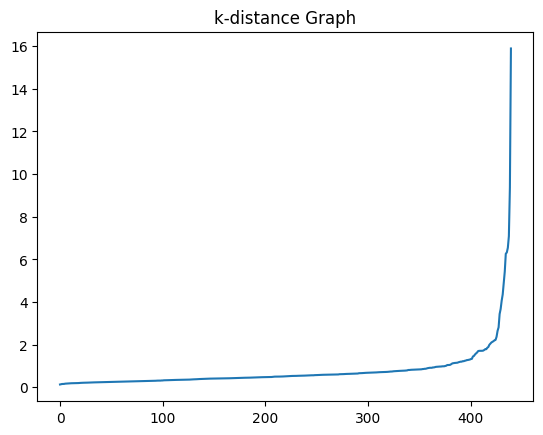

In [ ]:
from sklearn.neighbors import NearestNeighbors
import numpy as np

neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_scaled)

distances, indices = neighbors_fit.kneighbors(X_scaled)

distances = np.sort(distances[:, 4])

plt.plot(distances)
plt.title("k-distance Graph")
plt.show()

In [ ]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=2.5, min_samples=5)
labels_dbscan = dbscan.fit_predict(X_scaled)

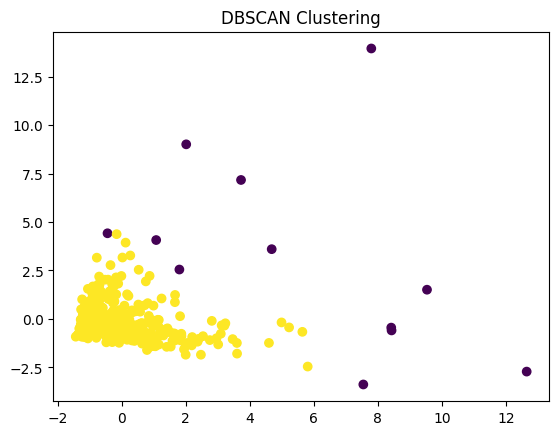

In [ ]:
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_dbscan, cmap='viridis')
plt.title("DBSCAN Clustering")
plt.show()

In [ ]:
import numpy as np

np.unique(labels_dbscan)

array([-1,  0])

## Conclusion
The silhouette score indicated that two clusters offered the best separation, whereas the elbow technique recommended an ideal number of clusters around five. K-Means with k=2 was therefore chosen.
Similar to K-Means, agglomerative clustering identified two major clusters in the sample. One primary cluster and a number of outliers were found using DBSCAN, suggesting the existence of dense regions and anomalies.

K-Means and Agglomerative clustering both revealed consistent cluster structures and suggest that the dataset naturally forms two main groups. K-Means is efficient and works well with spherical clusters, while Agglomerative clustering provides a hierarchical interpretation.
DBSCAN is effective at detecting outliers and clusters of arbitrary shapes, but it is highly sensitive to parameter selection. In this case, DBSCAN identified a dominant cluster and labeled several points as noise.
As a result, K-Means and Agglomerative clustering are more suitable for this dataset, while DBSCAN is useful for identifying anomalies.